In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("/content/campaign_responses.csv")

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")



 dataframe head :    customer_id  age  gender  annual_income  credit_score employed  \
0            1   35    Male          65000           720      Yes   
1            2   28  Female          45000           680       No   
2            3   42    Male          85000           750      Yes   
3            4   31  Female          55000           710      Yes   
4            5   47    Male          95000           790      Yes   

  marital_status  no_of_children responded  
0        Married               2       Yes  
1         Single               0        No  
2        Married               3       Yes  
3         Single               1        No  
4        Married               2       Yes  
 dataframe shape : (56, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     56 non-null     int64 
 1   age             56 non-null    

In [54]:
y = df['responded']
df.drop(['customer_id','responded'], axis = 1, inplace = True)
x = df

for col in x.columns:
  if x[col].dtype == 'object':
    x[col] = LabelEncoder().fit_transform(x[col])
  else:
    x[col] = StandardScaler().fit_transform(x[col].values.reshape(-1, 1))


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(44, 7)
(12, 7)
(44,)
(12,)


In [55]:
y_train.value_counts()

,count
responded,
No,23
Yes,21


In [57]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)
print(y_train.value_counts())

responded
Yes    23
No     23
Name: count, dtype: int64


In [58]:
print(x)

         age  gender  annual_income  credit_score  employed  marital_status  \
0  -0.172859       1      -0.177936      0.014931         1               0   
1  -1.169337       0      -1.063659     -0.653970         0               1   
2   0.823620       1       0.707788      0.516607         1               0   
3  -0.742275       0      -0.620797     -0.152294         1               1   
4   1.535390       1       1.150650      1.185508         1               0   
5  -1.596399       0      -1.373663     -1.490097         0               1   
6   0.396558       1       0.132068      0.349381         1               0   
7  -0.457567       0      -0.930801     -0.821196         1               1   
8   2.104807       1       1.814943      1.687184         1               0   
9  -1.311691       0      -1.285090     -1.657322         0               1   
10  1.108328       1       0.929219      1.018283         1               0   
11 -0.884629       0      -0.753656     -0.486745   

In [59]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Encode the target variable (Disease) from string labels to numerical labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Change model to XGBClassifier as the task is classification (predicting disease categories)
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1)

xgb_model.fit(x_train, y_train_encoded)

y_pred_encoded = xgb_model.predict(x_test)

accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
report = classification_report(y_test_encoded, y_pred_encoded, target_names=le.classes_)

print(f"Accuracy: {accuracy}\n")
print("Classification Report:\n", report)

Accuracy: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

          No       0.71      1.00      0.83         5
         Yes       1.00      0.71      0.83         7

    accuracy                           0.83        12
   macro avg       0.86      0.86      0.83        12
weighted avg       0.88      0.83      0.83        12



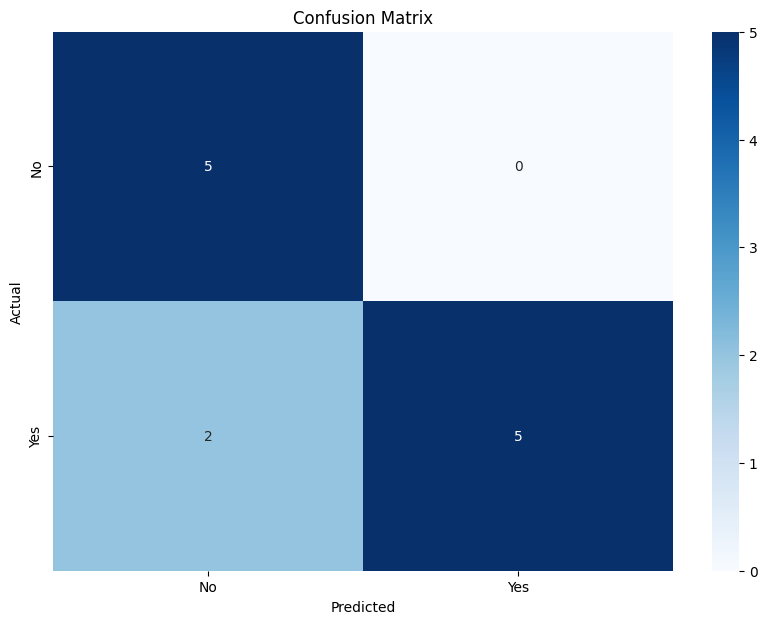

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [61]:
import joblib

joblib.dump(xgb_model, "xg boost model")
print("Model saved as xg boost ")

Model saved as xg boost 
